In [1]:
import pandas as pd

TITANIC_URL = (
  'https://raw.githubusercontent.com/'
  'datasciencedojo/datasets/master/titanic.csv'
)
titanic = pd.read_csv(TITANIC_URL)

In [4]:
import matplotlib.pyplot as plt
import platform

# Set the font family based on your operating system
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux / Ubuntu
    plt.rcParams['font.family'] = 'NanumGothic'

# Crucial: Fixes the minus sign rendering issue when changing fonts
plt.rcParams['axes.unicode_minus'] = False

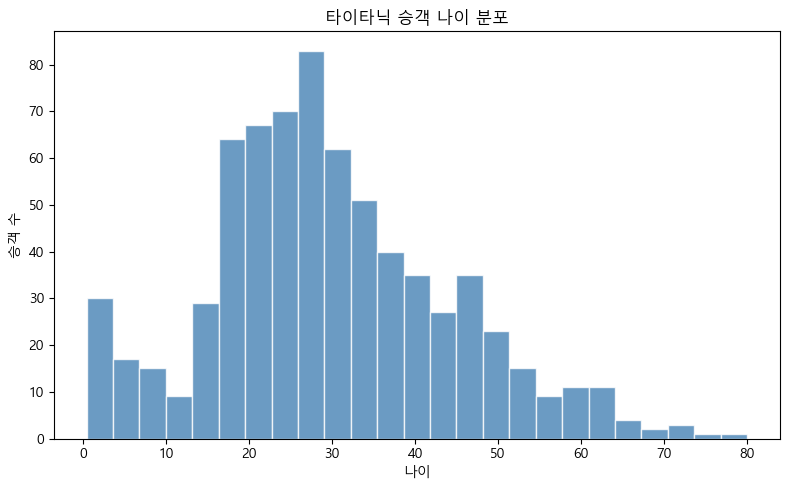

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(titanic['Age'],
        bins=25,
        color='steelblue',
        edgecolor='white',
        alpha=0.8)
ax.set_xlabel('나이')
ax.set_ylabel('승객 수')
ax.set_title('타이타닉 승객 나이 분포')
plt.tight_layout()
plt.show()

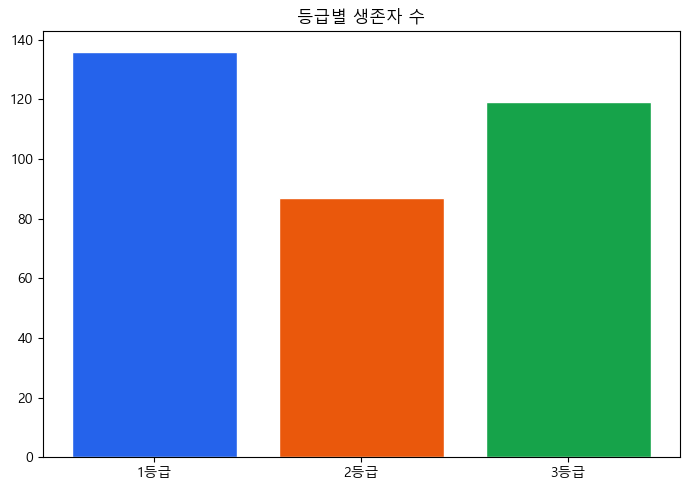

In [6]:
surv_class = titanic.groupby('Pclass')['Survived'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(surv_class.index, surv_class.values,
       color=['#2563eb','#ea580c','#16a34a'],
       edgecolor='white')
ax.set_title('등급별 생존자 수')
ax.set_xticks([1,2,3])
ax.set_xticklabels(['1등급','2등급','3등급'])
plt.tight_layout(); plt.show()

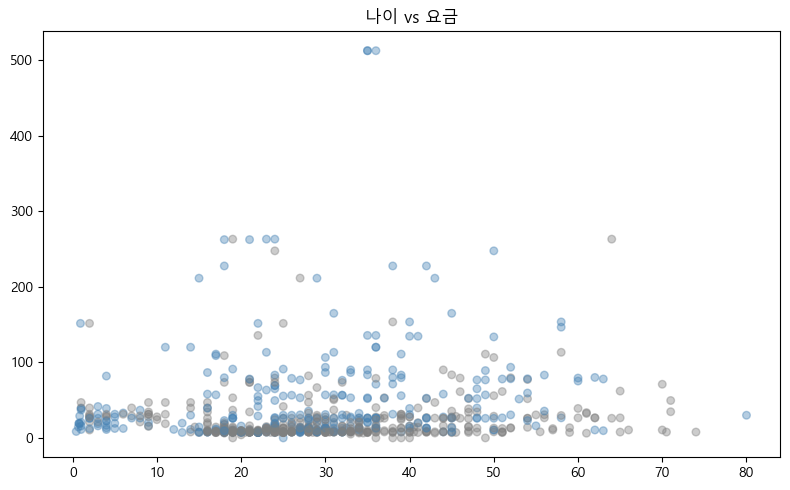

In [8]:
colors = titanic['Survived'].map(
    {0: 'gray', 1: 'steelblue'})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(titanic['Age'],
           titanic['Fare'],
           c=colors, alpha=0.4, s=30)
ax.set_title('나이 vs 요금')
plt.tight_layout(); plt.show()

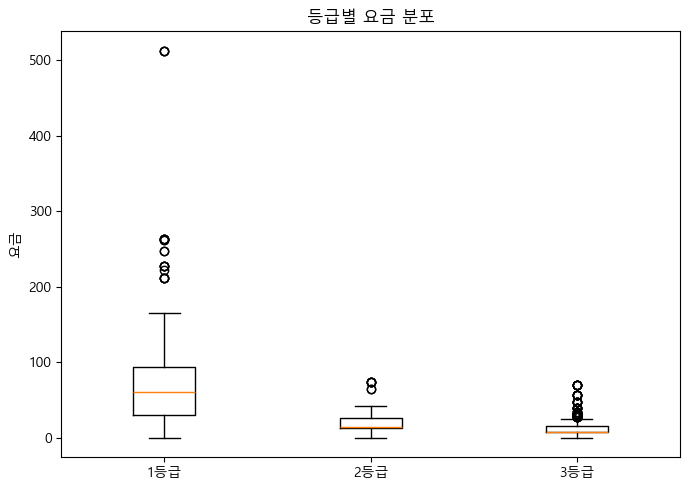

In [9]:
data = [titanic[titanic['Pclass']==c]['Fare'].dropna()
        for c in [1,2,3]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data,
           tick_labels=['1등급','2등급','3등급'])
ax.set_ylabel('요금')
ax.set_title('등급별 요금 분포')
plt.tight_layout(); plt.show()

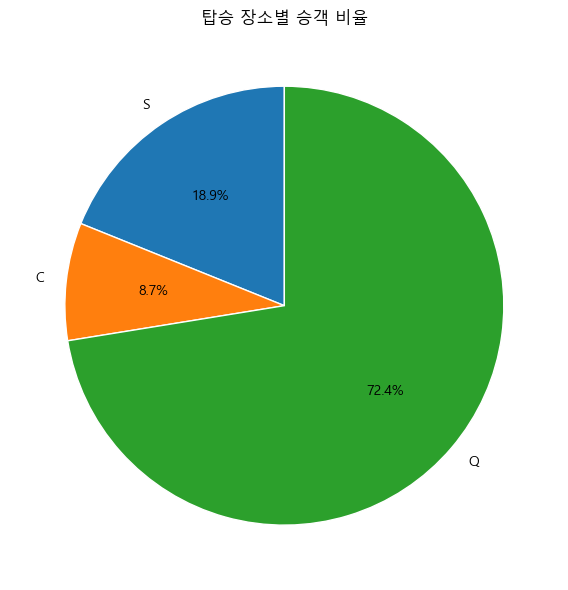

In [14]:
class_counts = titanic['Embarked'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(class_counts.values,
       labels=['S','C','Q'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('탑승 장소별 승객 비율')
plt.tight_layout(); plt.show()

In [15]:
imdb = pd.read_csv('./imdb_top_1000.csv')
imdb.shape   # (1000, 16)

(1000, 16)

In [24]:
# imdb 평점 히스토그램
# 투표수 vs 평점 scatter
# HTML 저장
import plotly.express as px

fig = px.histogram(
    imdb,
    x='IMDB_Rating',
    nbins=20,
    title='IMDB 평점 분포',
    template='simple_white'
)
fig.show()
fig.write_html('imdb_histogram.html')

In [ ]:
fig = px.scatter(
    imdb,
    x='No_of_Votes',
    y='IMDB_Rating',
    hover_name='Series_Title',
    hover_data=['Released_Year',
                'Genre'],
    title='투표 수 vs IMDB 평점',
    template='simple_white',
    opacity=0.6
)
fig.show()
fig.write_html('imdb_scatter.html')

In [25]:
# 서울 아파트
# 월별 평균가격 꺾은선
# 월별 거래 건수 막대
# 구별 평균 가격 수평 막대
# 최근 3년 가격 추이
# HTML 저장

sa = pd.read_csv('./seoul_apartment.csv')
sa.shape   # (1260226, 13)

(1260226, 13)

In [ ]:
# 월별 평균 거래금액 계산
monthly = (
    sa.groupby('계약년월')['거래금액(만원)']
    .mean()
    .reset_index()
)
monthly.columns = ['계약년월', '평균거래금액']

# ✅ 문자열로 변환
monthly['계약년월'] = monthly['계약년월'].astype(str)

fig = px.line(
    monthly,
    x='계약년월',
    y='평균거래금액',
    title='서울 아파트 월별 평균 거래가격',
    template='simple_white'
)
fig.update_xaxes(tickangle=45, nticks=24)
fig.show()

In [27]:
# 월별 거래 건수
cnt = (sa.groupby('계약년월')['NO']
       .count().reset_index())
cnt.columns = ['계약년월', '거래건수']
cnt['계약년월'] = cnt['계약년월'].astype(str)

fig = px.bar(cnt, x='계약년월', y='거래건수',
             template='simple_white')
fig.update_xaxes(tickangle=45, nticks=24)
fig.show()

In [28]:
# 구별 평균 가격 수평 막대
sa['구'] = sa['시군구'].str.split().str[1]

gu = (sa.groupby('구')['거래금액(만원)']
      .mean()
      .sort_values(ascending=True)
      .reset_index())

fig = px.bar(
    gu, x='거래금액(만원)', y='구',
    orientation='h',
    color='거래금액(만원)',
    color_continuous_scale='Blues',
    title='서울 자치구별 평균 아파트 거래가격',
    template='simple_white'
)
fig.show()

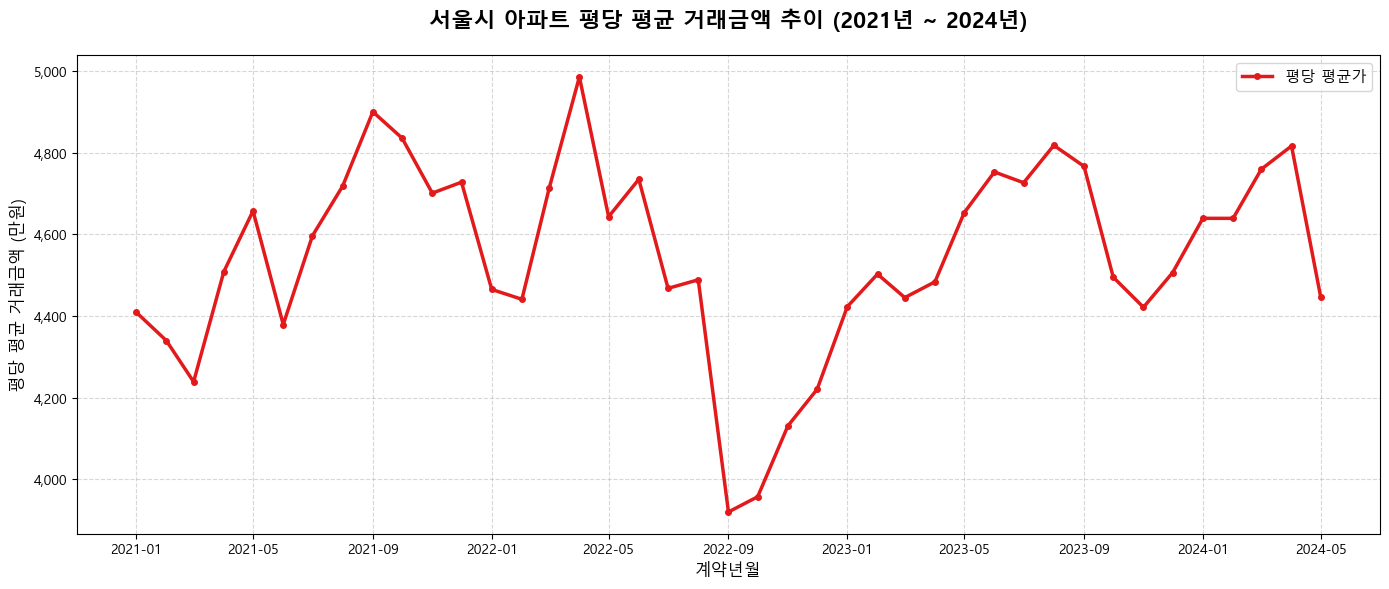

In [42]:
import platform
from matplotlib.ticker import StrMethodFormatter

# 1. 한글 폰트 및 마이너스 기호 깨짐 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

sa['계약년월'] = pd.to_datetime(sa['계약년월'].astype(str), format='mixed')

if sa['거래금액(만원)'].dtype == 'object':
    sa['거래금액(만원)'] = sa['거래금액(만원)'].str.replace(',', '').astype(int)

sa['평당금액'] = sa['거래금액(만원)'] / (sa['전용면적(㎡)'] / 3.3)

df_recent = sa[(sa['계약년월'] >= '2021-01-01') & (sa['계약년월'] <= '2024-12-31')]

monthly_trend = df_recent.groupby('계약년월')['평당금액'].mean().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(monthly_trend['계약년월'], monthly_trend['평당금액'], color='#e31a1c', linewidth=2.5, marker='o', markersize=4, label='평당 평균가')

plt.title('서울시 아파트 평당 평균 거래금액 추이 (2021년 ~ 2024년)', fontsize=16, pad=20, weight='bold')
plt.xlabel('계약년월', fontsize=12)
plt.ylabel('평당 평균 거래금액 (만원)', fontsize=12)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [18]:
#imdb 장르 심화
# 장르별 평균 평점 바
# 연도별 평점 추이 scatter
# gross 정제 후 흥행 vs 평점

In [37]:
imdb['Main_Genre'] = imdb['Genre'].str.split(',').str[0].str.strip()

genre_stats = imdb.groupby('Main_Genre').agg(
    Avg_Rating=('IMDB_Rating', 'mean'),
    Movie_Count=('Series_Title', 'count')
).reset_index()

genre_stats = genre_stats.sort_values(by='Avg_Rating', ascending=False)

fig_bar = px.bar(
    genre_stats,
    x='Main_Genre',
    y='Avg_Rating',
    text_auto='.2f',
    hover_data=['Movie_Count'],
    title='장르별 평균 평점 (대표 장르 기준)',
    labels={'Main_Genre': '장르', 'Avg_Rating': '평균 평점', 'Movie_Count': '영화 수'},
    template='simple_white'
)

fig_bar.update_yaxes(range=[7.0, 9.5])

fig_bar.show()

In [40]:
imdb['Released_Year_Num'] = pd.to_numeric(imdb['Released_Year'], errors='coerce')
imdb_year_clean = imdb.dropna(subset=['Released_Year_Num'])

fig = px.scatter(
    imdb_year_clean,
    x='Released_Year_Num',
    y='IMDB_Rating',
    hover_name='Series_Title',
    hover_data=['Genre', 'Gross_M'],
    trendline='lowess',
    trendline_color_override='red',
    title='개봉 연도별 평점 추이 및 분포',
    labels={'Released_Year_Num': '개봉 연도', 'IMDB_Rating': '평점 (IMDB Rating)'},
    template='simple_white',
    opacity=0.5
)

fig.show()

In [34]:
import pandas as pd
import numpy as np

imdb = pd.read_csv('./imdb_top_1000.csv')

imdb['Gross'] = imdb['Gross'].str.replace(',', '')
imdb['Gross'] = pd.to_numeric(imdb['Gross'], errors='coerce')

imdb['Gross'] = imdb['Gross'].fillna(0)

imdb['Gross_M'] = imdb['Gross'] / 1000000

In [35]:
# 상위 5개 데이터의 정제 결과 확인
print(imdb[['Series_Title', 'Gross', 'Gross_M']].head())

# 데이터 타입이 float64(숫자)로 잘 바뀌었는지 확인
print("\n--- 컬럼 정보 확인 ---")
imdb[['Gross', 'Gross_M']].info()

               Series_Title        Gross     Gross_M
0  The Shawshank Redemption   28341469.0   28.341469
1             The Godfather  134966411.0  134.966411
2           The Dark Knight  534858444.0  534.858444
3    The Godfather: Part II   57300000.0   57.300000
4              12 Angry Men    4360000.0    4.360000

--- 컬럼 정보 확인 ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Gross    1000 non-null   float64
 1   Gross_M  1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [ ]:
import plotly.express as px

imdb_analyzed = imdb[imdb['Gross'] > 0]

fig = px.scatter(
    imdb_analyzed,
    x='Gross_M',              
    y='IMDB_Rating',          
    hover_name='Series_Title',
    hover_data=['Released_Year', 'Genre', 'No_of_Votes'],
    title='영화 흥행 수익 vs IMDB 평점 관계 분석',
    labels={'Gross_M': '흥행 수익 (백만 달러)', 'IMDB_Rating': '평점 (IMDB Rating)'},
    template='simple_white',
    opacity=0.6
)

fig.show()